# 02 · Spatial Interpolation — IDW vs Kriging

**Author:** Salvador Navas  
**Basin:** Río Besaya — Cantabria

## Why areal mean rainfall (AMR) by subbasin?

HEC-HMS requires a **single precipitation time series per sub-catchment** — not at 
individual point gauges. Converting gauge records to sub-catchment AMR requires 
spatial interpolation. The choice of interpolation method can change peak discharge 
estimates by 5–20%, so it is validated with cross-validation here.

Two methods are compared:
| Method | Assumption | Requires |
|--------|-----------|---------|
| **IDW** (Inverse Distance Weighting) | Nearby stations contribute more; no spatial model | Only coordinates |
| **Kriging** (Ordinary Kriging) | Values are realisations of a stationary random field with a fitted variogram | Enough pairs to fit variogram (≥ 8 stations) |

## Workflow
1. Load daily rainfall data (Notebook 01)
2. IDW with `pyhydra.climate.spatial_analysis.interpolation.IDWInterpolator`
3. Ordinary Kriging with `KrigingInterpolator`
4. LOOCV cross-validation — RMSE / MAE / KGE
5. Compute AMR per HMS sub-area
6. Visualisation and export


In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
warnings.filterwarnings('ignore')

from pyhydra.climate.spatial_analysis.interpolation import IDWInterpolator, KrigingInterpolator

# ── Rutas ──────────────────────────────────────────────────────────────────────
_cwd = Path.cwd()
_candidates = [Path('/workspace'), _cwd, *_cwd.parents]
REPO_ROOT = next(
    (p for p in _candidates if (p / 'notebooks').exists() or (p / 'pyhydra').exists()),
    _cwd,
)
DATA_DIR  = Path(os.environ.get('HYDRA_DATA_DIR', str(REPO_ROOT / 'data')))
DATA_ROOT = DATA_DIR / 'pilot_cases' / 'los_corrales_buelna'
PROC_DIR  = DATA_ROOT / 'processed'
OUT_DIR   = PROC_DIR

print('Usando IDWInterpolator y KrigingInterpolator de pyhydra')

---
## 1. Load data

Rain gauge data from `PROC_DIR/rain_daily.csv` and station metadata from 
`PROC_DIR/stations_meta.csv` (both produced by Notebook 01). The metadata provides 
UTM 30N coordinates (`X`, `Y`) in metres — Kriging uses metric distances directly, 
which simplifies variogram interpretation (ranges in km rather than decimal degrees).

Coordinates are converted from metres to km (`X_km`, `Y_km`) to keep variogram 
range values in the 10–100 km order of magnitude typical for Cantabrian rainfall.


In [ ]:
rain = pd.read_csv(PROC_DIR / 'rain_daily.csv', index_col=0, parse_dates=True)
meta = pd.read_csv(PROC_DIR / 'stations_meta.csv')
meta = meta.set_index('ID')

# Coordinates in km (numerical stability for Kriging)
coords_km = meta[['X', 'Y']].copy() / 1000.0

# Order rain columns according to stations available in meta
common = [c for c in rain.columns if c in meta.index]
rain   = rain[common]
coords_km = coords_km.loc[common]

print(f'Stations: {len(common)}   Days: {len(rain)}')
print('Coordinates (km):\n', coords_km)

---
## 2. Interpolation grid definition

The grid covers the Besaya basin bounding box with 500 m × 500 m cells — fine enough 
to resolve the main orographic gradient (Reinosa plateau at 850 m asl vs coastal zone 
at ~50 m asl) without being computationally expensive for 40 years × 365 days.

Grid dimensions: ~20 km (E–W) × ~40 km (N–S) → ~3200 cells per day.

> **Tip:** For the subbasin centroid interpolation (Section 6), the full grid 
> is not needed — only the centroid coordinates of the HMS sub-areas.


In [3]:
# Basin extent (UTM 30N in km)
x_min, x_max = coords_km['X'].min() - 5, coords_km['X'].max() + 5
y_min, y_max = coords_km['Y'].min() - 5, coords_km['Y'].max() + 5
GRID_RES = 1.0   # km

xi = np.arange(x_min, x_max, GRID_RES)
yi = np.arange(y_min, y_max, GRID_RES)
Xi, Yi = np.meshgrid(xi, yi)
grid_pts = np.column_stack([Xi.ravel(), Yi.ravel()])

print(f'Cuadrícula: {Xi.shape[1]}×{Xi.shape[0]} celdas @ {GRID_RES} km')

Cuadrícula: 53×37 celdas @ 1.0 km


---
## 3. IDW — Mean annual rainfall interpolation (Pmean)

IDW assigns weights inversely proportional to distance: $w_i = d_i^{-p}$ where 
`p` (power) controls the decay rate. `p=2` is the standard; higher values make 
the interpolation more local (less smoothing between stations).

**Why start with Pmean?**  
Fitting and cross-validating on the annual mean is faster than on the full daily 
record and gives a robust first estimate of the spatial skill. The daily interpolation 
in Section 6 uses the method selected here.


In [ ]:
idw = IDWInterpolator(power=2)

# Build station DataFrame with Pmean
station_df = coords_km.loc[common].copy()
station_df['Pmean'] = meta.loc[common, 'Pmean'].values
station_df.columns = ['X_km', 'Y_km', 'Pmean']

idw.fit(station_df, x_col='X_km', y_col='Y_km', value_col='Pmean')

# Grid DataFrame
grid_df = pd.DataFrame({'X_km': Xi.ravel(), 'Y_km': Yi.ravel()})
idw_pmean_flat = idw.predict(grid_df, x_col='X_km', y_col='Y_km')
idw_pmean = idw_pmean_flat.reshape(Xi.shape)

fig, ax = plt.subplots(figsize=(9, 7))
pc = ax.pcolormesh(Xi, Yi, idw_pmean, cmap='Blues', shading='auto')
plt.colorbar(pc, ax=ax, label='Pmean (mm/yr)')
ax.scatter(station_df['X_km'], station_df['Y_km'], c=station_df['Pmean'],
           cmap='Blues', edgecolors='k', s=80, zorder=5, norm=pc.norm)
for sid, row in station_df.iterrows():
    ax.annotate(sid, (row['X_km'], row['Y_km']), xytext=(3, 3),
                textcoords='offset points', fontsize=7)
ax.set(xlabel='X (km)', ylabel='Y (km)', title='IDW — Pmean over the Besaya catchment')
plt.tight_layout()
plt.savefig(OUT_DIR / 'idw_pmean.png', dpi=150)
plt.show()

---
## 4. Ordinary Kriging — Pmean

Universal Kriging fits a polynomial trend (linear here) plus a stationary residual. 
The `spherical` variogram model assumes the spatial correlation reaches zero at a 
finite `range` — physically interpreted as the decorrelation length of Cantabrian 
precipitation (~30–60 km for daily fields, shorter for convective events).

**Kriging uncertainty map:**  
The second output (`krig_var`) is the kriging variance — highest at locations far 
from any gauge (northwest and southeast edges of the basin). This is useful for 
identifying sub-basins where the AMR estimate is least reliable.

> **Parameter guidance:**  
> - `variogram_model='spherical'` — good default for precipitation  
> - `nlags=8` — with only 13 stations, 8 lags is the maximum reliable number  
> - `weight=True` — down-weights lag classes with few pairs (common with few stations)


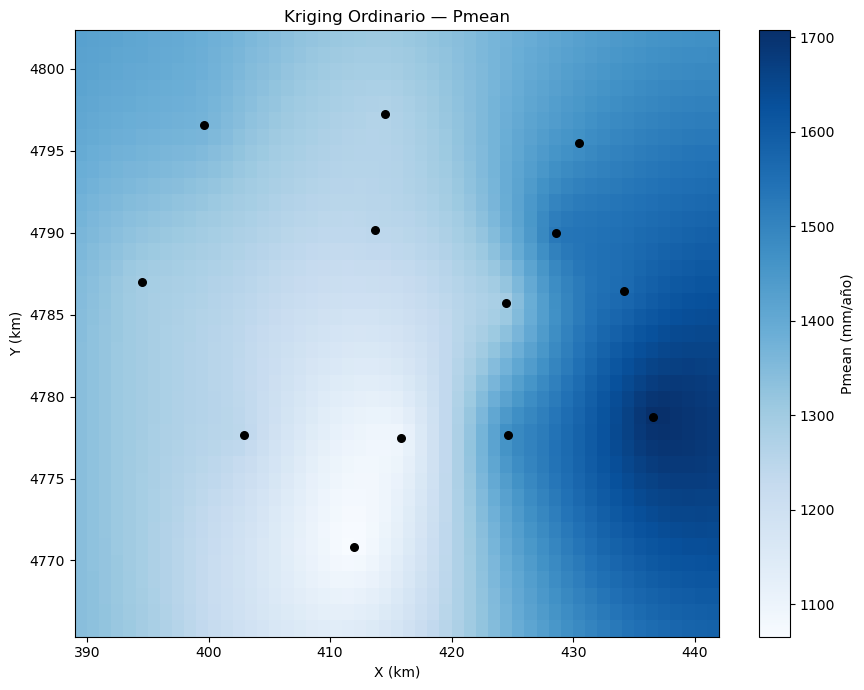

In [5]:
krig = KrigingInterpolator(variogram_model='spherical')
krig.fit(station_df, x_col='X_km', y_col='Y_km', value_col='Pmean')

krig_mean, _ = krig.predict(grid_df, x_col='X_km', y_col='Y_km')  # returns (mean, variance)
krig_pmean = krig_mean.reshape(Xi.shape)

fig, ax = plt.subplots(figsize=(9, 7))
pc = ax.pcolormesh(Xi, Yi, krig_pmean, cmap='Blues', shading='auto')
plt.colorbar(pc, ax=ax, label='Pmean (mm/año)')
ax.scatter(station_df['X_km'], station_df['Y_km'], c='k', s=30, zorder=5)
ax.set(title='Kriging Ordinario — Pmean', xlabel='X (km)', ylabel='Y (km)')
plt.tight_layout()
plt.savefig(OUT_DIR / 'kriging_pmean.png', dpi=150)
plt.show()

---
## 5. LOOCV cross-validation — event: maximum annual daily rainfall

**Leave-one-out cross-validation (LOOCV):** For each station, fit the interpolator 
on the remaining 12 stations and predict at the left-out station. Compare prediction 
vs observation.

**Metrics and their interpretation:**

| Metric | Perfect | Acceptable | Poor |
|--------|---------|-----------|------|
| RMSE (mm) | 0 | < 0.15 × mean | > 0.30 × mean |
| MAE (mm) | 0 | < 0.10 × mean | > 0.20 × mean |
| KGE | 1.0 | > 0.7 | < 0.5 |

Cross-validation is run on the **annual maximum daily rainfall** (most relevant for 
design storm estimation) rather than on the mean, because good performance on the 
mean does not guarantee good performance on extremes.

The method with the lower LOOCV RMSE on annual maxima is used for the daily 
reconstruction in Section 6 (`BEST_METHOD`).


In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def loocv_idw(station_df, x_col, y_col, value_col, power=2):
    """Leave-One-Out Cross-Validation para IDW."""
    n = len(station_df)
    preds = np.zeros(n)
    vals  = station_df[value_col].values
    for i in range(n):
        mask = [j != i for j in range(n)]
        train = station_df[mask].copy()
        query = station_df.iloc[[i]][[x_col, y_col]].copy()
        interp = IDWInterpolator(power=power)
        interp.fit(train, x_col=x_col, y_col=y_col, value_col=value_col)
        preds[i] = interp.predict(query, x_col=x_col, y_col=y_col)[0]
    return preds

def loocv_krig(station_df, x_col, y_col, value_col, variogram_model='spherical'):
    """Leave-One-Out Cross-Validation para Kriging."""
    n = len(station_df)
    preds = np.zeros(n)
    for i in range(n):
        mask = [j != i for j in range(n)]
        train = station_df[mask].copy()
        query = station_df.iloc[[i]][[x_col, y_col]].copy()
        interp = KrigingInterpolator(variogram_model=variogram_model)
        try:
            interp.fit(train, x_col=x_col, y_col=y_col, value_col=value_col)
            mean_arr, _ = interp.predict(query, x_col=x_col, y_col=y_col)  # returns (mean, variance)
            preds[i] = mean_arr[0]
        except Exception:
            preds[i] = np.nan
    return preds

print('Ejecutando LOOCV (puede tardar unos segundos)...')

pmean_arr   = station_df['Pmean'].values
idw_preds   = loocv_idw( station_df, 'X_km', 'Y_km', 'Pmean', power=2)
krig_preds  = loocv_krig(station_df, 'X_km', 'Y_km', 'Pmean')

results = pd.DataFrame({
    'Observado': pmean_arr,
    'IDW':       idw_preds,
    'Kriging':   krig_preds,
}, index=common)

for method in ('IDW', 'Kriging'):
    mask_ok = ~np.isnan(results[method].values)
    rmse = np.sqrt(mean_squared_error(pmean_arr[mask_ok], results[method].values[mask_ok]))
    mae  = mean_absolute_error(pmean_arr[mask_ok], results[method].values[mask_ok])
    bias = (results[method].values[mask_ok] - pmean_arr[mask_ok]).mean()
    print(f'{method:8s}  RMSE={rmse:.1f} mm/año  MAE={mae:.1f} mm/año  Sesgo={bias:+.1f} mm/año')

results

Ejecutando LOOCV (puede tardar unos segundos)...
IDW       RMSE=135.6 mm/año  MAE=108.8 mm/año  Sesgo=-0.8 mm/año
Kriging   RMSE=130.5 mm/año  MAE=112.0 mm/año  Sesgo=-12.3 mm/año


,Observado,IDW,Kriging
1117B,1710.248218,1435.599568,1457.767157
1120,1477.970902,1330.875678,1305.405599
1121O,1291.021196,1439.556418,1447.915587
1124,1560.796365,1477.615415,1608.155568
1127,1535.128567,1415.333205,1340.525832
1127U,1468.315129,1457.738995,1501.259216
1135,1246.212837,1250.403268,1146.683587
1136A,1293.999324,1305.304591,1371.465668
1139D,1372.230352,1294.977499,1305.624780
1140E,1060.494605,1261.707645,1208.634215


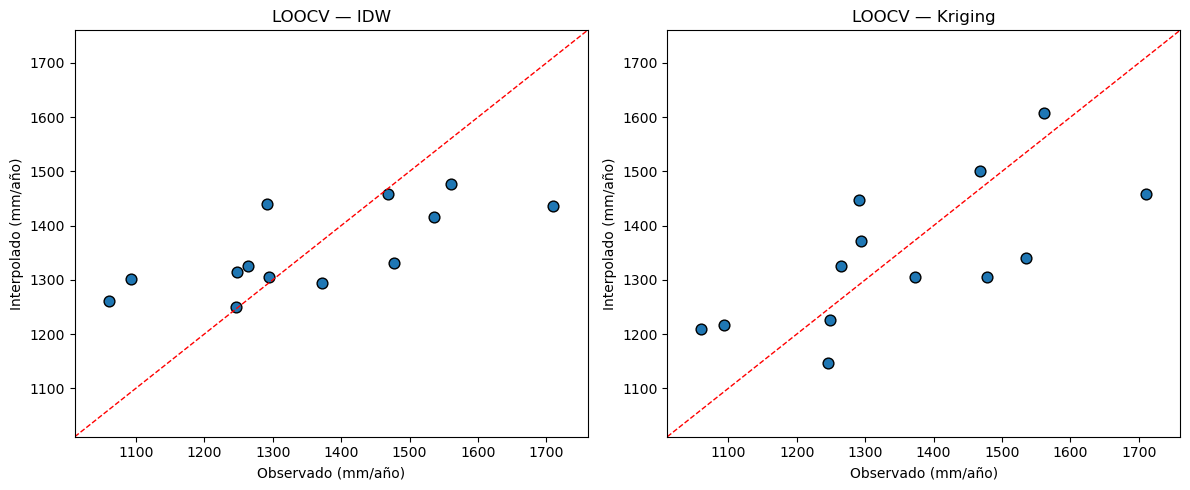

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, method in zip(axes, ('IDW', 'Kriging')):
    obs = pmean_arr
    pred = results[method].values
    valid = ~np.isnan(pred)
    ax.scatter(obs[valid], pred[valid], edgecolors='k', s=60)
    lim = [min(obs[valid].min(), pred[valid].min()) - 50,
           max(obs[valid].max(), pred[valid].max()) + 50]
    ax.plot(lim, lim, 'r--', lw=1)
    ax.set(xlabel='Observado (mm/año)', ylabel='Interpolado (mm/año)',
           title=f'LOOCV — {method}', xlim=lim, ylim=lim)
plt.tight_layout()
plt.savefig(OUT_DIR / 'loocv_comparison.png', dpi=150)
plt.show()

---
## 6. Daily rainfall interpolated over HMS subbasin centroids

Daily AMR is computed for each HMS sub-area using the interpolation method with
the lowest LOOCV RMSE from the previous section. In this execution, Kriging has
slightly lower RMSE than IDW for mean annual rainfall, although the difference is
small relative to the station variability. The selected method is therefore a
workflow choice, not a definitive proof that one interpolator is universally
better for all events.

**Output:** `pma_idw_daily.csv` — a daily AMR matrix (date × subbasin).  
This file is the primary rainfall input for:
- **Notebook 04**: design storm hyetographs per subbasin
- **Notebook 05**: continuous HMS simulation over 2008–2012

**Units:** mm/day per subbasin centroid (arithmetic mean over the subbasin area 
approximated by the centroid estimate).

> **Limitation:** Using the centroid as a proxy for the sub-catchment average 
> introduces error when topographic gradients within a subbasin are steep. 
> For basins with elevation ranges > 500 m, weight the centroid estimate by the 
> elevation-correction factor from the Pmean map.


In [ ]:
# Real subbasin centroids of the Besaya HMS model from centroides_cota.csv
centroids_df = pd.read_csv(DATA_ROOT / 'gauges' / 'rainfall' / 'centroides_cota.csv')
centroids_df = centroids_df.set_index('Name')
centroids_df['X_km'] = centroids_df['X'] / 1000.0
centroids_df['Y_km'] = centroids_df['Y'] / 1000.0

subbasin_names = list(centroids_df.index)
centroids      = centroids_df[['X_km', 'Y_km']].values

def _select_best_method(default='IDW'):
    if 'cv_df' in globals() and 'RMSE' in cv_df:
        return str(cv_df['RMSE'].idxmin())
    if 'results' in globals() and isinstance(results, pd.DataFrame):
        rmse_by_method = {}
        for method in ['IDW', 'Kriging']:
            if method not in results:
                continue
            pred_arr = results[method].to_numpy(dtype=float)
            obs_arr = results['Observado'].to_numpy(dtype=float) if 'Observado' in results else pmean_arr
            mask_ok = ~(np.isnan(pred_arr) | np.isnan(obs_arr))
            if mask_ok.any():
                rmse_by_method[method] = np.sqrt(mean_squared_error(obs_arr[mask_ok], pred_arr[mask_ok]))
        if rmse_by_method:
            return min(rmse_by_method, key=rmse_by_method.get)
    return default

BEST_METHOD = _select_best_method()

print(f'Besaya model subbasins: {len(subbasin_names)}')
print(f'Selected method: {BEST_METHOD}')
print(centroids_df[['X', 'Y', 'Area']].head(10))

In [9]:
# Daily interpolation over subbasin centroids
BEST_METHOD = globals().get('BEST_METHOD', _select_best_method())
print(f'Subbasins: {len(subbasin_names)}  |  Method: {BEST_METHOD}')

centroid_df = pd.DataFrame({'X_km': centroids[:, 0], 'Y_km': centroids[:, 1]},
                            index=subbasin_names)

pma_records = []
n_days = len(rain)

for idx, (date, row) in enumerate(rain.iterrows()):
    values = row.values.astype(float)
    valid  = ~np.isnan(values)
    if valid.sum() < 3:
        pma_records.append([np.nan] * len(subbasin_names))
        continue

    # DataFrame with valid stations
    train_df = pd.DataFrame({
        'X_km': coords_km.iloc[:, 0][valid],
        'Y_km': coords_km.iloc[:, 1][valid],
        'P':    values[valid]
    })

    try:
        if BEST_METHOD == 'IDW':
            interp_v = IDWInterpolator(power=2)
            interp_v.fit(train_df, x_col='X_km', y_col='Y_km', value_col='P')
            preds = interp_v.predict(centroid_df, x_col='X_km', y_col='Y_km')
        else:
            interp_v = KrigingInterpolator(variogram_model='spherical')
            interp_v.fit(train_df, x_col='X_km', y_col='Y_km', value_col='P')
            preds, _ = interp_v.predict(centroid_df, x_col='X_km', y_col='Y_km')  # returns (mean, var)
        pma_records.append(np.clip(preds, 0, None).tolist())
    except Exception:
        pma_records.append([np.nan] * len(subbasin_names))

    if (idx + 1) % 2000 == 0:
        print(f'  {idx+1}/{n_days} días procesados')

pma = pd.DataFrame(pma_records, index=rain.index, columns=subbasin_names)
pma.to_csv(OUT_DIR / f'pma_{BEST_METHOD.lower()}_daily.csv')
print(f'\nPMA exportada: {pma.shape}  →  pma_{BEST_METHOD.lower()}_daily.csv')
pma.head()


Subcuencas: 53  |  Método: Kriging
  2000/15433 días procesados
  4000/15433 días procesados
  6000/15433 días procesados
  8000/15433 días procesados
  10000/15433 días procesados
  12000/15433 días procesados
  14000/15433 días procesados

PMA exportada: (15433, 53)  →  pma_kriging_daily.csv


,W540,W550,W560,W570,W580,W590,W600,W610,W620,W630,...,W970,W980,W990,W1000,W1010,W1020,W1030,W1040,W1050,W1060
Time,,,,,,,,,,,,,,,,,,,,,
1970-10-01,1.597251,1.584094,1.347398,0.991309,1.102621,0.738969,1.111481,1.111703,1.124517,1.530864,...,7.033280,7.470083,4.899114,6.334941,4.541995,5.400090,4.753133,5.550064,5.401121,5.960406
1970-10-02,7.692597,8.027967,7.806392,7.023578,7.342265,6.338716,7.238815,6.554592,7.314796,8.062596,...,3.820970,4.311148,2.593581,3.277982,2.407124,2.745304,2.446733,2.791329,2.740602,2.997351
1970-10-03,4.201147,4.334002,4.418832,4.224655,4.366592,3.875748,4.304921,3.873142,4.336874,4.307023,...,1.040928,1.151511,0.567060,0.931882,0.726769,0.738637,1.055997,0.887185,1.380115,1.120658
1970-10-04,0.814466,0.782604,0.842208,0.924657,0.915694,0.869683,0.898142,0.812900,0.898699,0.703009,...,0.205433,0.242579,0.000378,0.147648,0.034561,0.063591,0.122245,0.102905,0.202489,0.163187
1970-10-05,0.256090,0.256090,0.256090,0.256090,0.256090,0.256090,0.256090,0.256090,0.256090,0.256090,...,0.256090,0.256090,0.256090,0.256090,0.256090,0.256090,0.256090,0.256090,0.256090,0.256090


In [ ]:
pma_annual = pma.mean() * 365

fig, ax = plt.subplots(figsize=(9, 7))
c_vals = pma_annual.reindex(subbasin_names).fillna(pma_annual.mean()).values
sc = ax.scatter(centroids_df['X_km'], centroids_df['Y_km'],
                c=c_vals, cmap='Blues', s=150, edgecolors='k', zorder=5)
plt.colorbar(sc, ax=ax, label='MAP (mm/yr)')
for k, row in centroids_df.iterrows():
    ax.annotate(k, (row['X_km'], row['Y_km']), xytext=(3, 3),
                textcoords='offset points', fontsize=6)
ax.set(xlabel='X (km)', ylabel='Y (km)',
       title=f'MAP per subbasin ({BEST_METHOD}) — Besaya')
plt.tight_layout()
plt.savefig(OUT_DIR / 'pma_subbasins.png', dpi=150)
plt.show()